In [ ]:
import torch
import hashlib
import numpy as np
from transformers import LogitsProcessor, LogitsProcessorList
from scipy.stats import norm
class GreenListWatermarkProcessor(LogitsProcessor):
  def __init__(self, vocab_size, gamma=0.5, delta=2.0, k=1):
    self.vocab_size = vocab_size
    self.gamma = gamma
    self.delta = delta
    self.k = k
    self.hashcode = 1000003
    if not (0 <= gamma <= 1):
        raise ValueError("gamma must be between 0 and 1")

  def __call__(self, input_ids: torch.LongTensor, scores: torch.FloatTensor) -> torch.FloatTensor:
    # Only process the last token for context
    # input_ids shape: (batch_size, sequence_length)
    # scores shape: (batch_size, vocab_size)

    # Assuming batch_size = 1 for simplicity in watermarking context
    if input_ids.shape[0] != 1:
        raise ValueError("GreenListWatermarkProcessor is designed for batch_size=1")

    prev_token = torch.min(input_ids[0, -self.k:]).item()

    # Initialize a numpy random number generator with the context-dependent seed
    rng = np.random.default_rng(self.hashcode*prev_token)

    # Determine the number of tokens to greenlist
    num_green_tokens = int(self.vocab_size * self.gamma)

    # Create a permutation of all token IDs
    all_tokens = np.arange(self.vocab_size)
    shuffled_tokens = rng.permutation(all_tokens)

    # Select green and red tokens for the current step
    green_list_tokens = shuffled_tokens[:num_green_tokens]
    # red_list_tokens = shuffled_tokens[num_green_tokens:] # Not needed if only boosting green list

    # Apply positive bias to green-listed tokens' logits
    # Create a boolean mask for green-listed tokens in the current vocabulary dimension
    green_mask = torch.zeros_like(scores, dtype=torch.bool, device=scores.device)
    green_mask[0, green_list_tokens] = True # Apply to the single batch item

    scores[green_mask] += self.delta

    # Original red list penalty logic (commented out or removed as per request)
    # red_mask = torch.zeros_like(scores, dtype=torch.bool, device=scores.device)
    # red_mask[0, red_list_tokens] = True
    # scores[red_mask] -= self.delta

    return scores

In [ ]:
class WatermarkDetector:
  def __init__(self, vocab_size, tokenizer, gamma=0.5, delta=2.0, k=1, hashcode=1000003):
    self.vocab_size = vocab_size
    self.gamma = gamma
    self.delta = delta
    self.k = k
    self.tokenizer = tokenizer
    self.hashcode = hashcode
    self.device = 0 if torch.cuda.is_available() else -1
    if not (0 <= gamma <= 1):
        raise ValueError("gamma must be between 0 and 1")
  def __call__(self, generated_text):
    tokens = self.tokenizer.encode(generated_text)
    green_count = 0
    for i in range(len(tokens) - self.k):
      input_ids = torch.tensor([tokens[i:i+self.k]])
      scores = torch.zeros((1, self.vocab_size))
      prev_token = torch.min(input_ids).item()

      # Initialize a numpy random number generator with the context-dependent seed
      rng = np.random.default_rng(self.hashcode*prev_token)

      # Determine the number of tokens to greenlist
      num_green_tokens = int(self.vocab_size * self.gamma)

      # Create a permutation of all token IDs
      all_tokens = np.arange(self.vocab_size)
      shuffled_tokens = rng.permutation(all_tokens)

      # Select green and red tokens for the current step
      green_list_tokens = shuffled_tokens[:num_green_tokens]
      # red_list_tokens = shuffled_tokens[num_green_tokens:] # Not needed if only boosting green list

      # Apply positive bias to green-listed tokens' logits
      # Create a boolean mask for green-listed tokens in the current vocabulary dimension
      green_mask = torch.zeros_like(scores, dtype=torch.bool, device=self.device)
      green_mask[0, green_list_tokens] = True # Apply to the single batch item
      next_token = tokens[i+self.k]
      green_count+= int(green_mask[0, next_token].item())

    T = len(tokens)
    # Calculate the z-score
    z_score = (green_count - T * self.gamma)/np.sqrt(T * self.gamma * (1 - self.gamma))
    p = norm.sf(z_score)
    return z_score, p

In [ ]:
class ParaphraseAttack:
  def __init__(self, pipeline):
    self.pipeline = pipeline
    self.template = """Rewrite naturally:
      {text}

      Paraphrase:
    """
  def __call__(self, text):
    prompt = self.template.format(text=text)
    return self.pipeline.generate(prompt)

In [ ]:
from math import log
class QWENPipeline:
  def __init__(self, model, tokenizer, processor=None):
    self.model = model
    self.tokenizer = tokenizer
    self.processor = processor

  def get_log_probs(self, prompt, target_token):
    messages = [
      {"role": "user", "content": prompt}
    ]
    text = self.tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )
    model_inputs = self.tokenizer([text], return_tensors="pt").to(self.model.device)
    output = self.model(
        **model_inputs
    )
    log_probs = torch.log_softmax(output.logits, dim=-1)
    probs = torch.softmax(output.logits, dim=-1)
    log_probs_last_token = log_probs[0, -1, :]
    target_token_id = self.tokenizer.encode(target_token)[0]
    log_prob_target_token = log_probs_last_token[target_token_id]
    return log_prob_target_token
  def generate(self, prompt, watermark=True, **kwargs):
    messages = [
      {"role": "user", "content": prompt}
    ]
    text = self.tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False
    )
    model_inputs = self.tokenizer([text], return_tensors="pt").to(self.model.device)
    # conduct text completion

    generated_ids = self.model.generate(
        **model_inputs,
        max_new_tokens=256,
        logits_processor=LogitsProcessorList([self.processor]) if (self.processor and watermark) else None,
    )
    output_ids = generated_ids[0][len(model_inputs.input_ids[0]):].tolist()
    content = self.tokenizer.decode(output_ids, skip_special_tokens=True).strip("\n")
    return content

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM
device = 0 if torch.cuda.is_available() else -1
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen3-4B")
model = AutoModelForCausalLM.from_pretrained("Qwen/Qwen3-4B").to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

In [ ]:
tokenizer_qwen_mini = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-1.5B-Instruct")
model_qwen_mini = AutoModelForCausalLM.from_pretrained("Qwen/Qwen2.5-1.5B-Instruct").to(device)

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

In [ ]:
processor = GreenListWatermarkProcessor(
  vocab_size=model.config.vocab_size,
  gamma=0.5, delta=2.0, k=1,
)
pipeline = QWENPipeline(model, tokenizer, processor)
pipeline_mini = QWENPipeline(model_qwen_mini, tokenizer_qwen_mini, processor=None)

In [ ]:
generation = pipeline.generate("When did Virgin Australia start operating?", watermark=False)

In [ ]:
generation

'Virgin Australia began operations on **15 September 1999**. It was the first airline to be wholly owned by Virgin Group, and it initially operated under the name **Virgin Blue** before rebranding to **Virgin Australia** in 2011.'

In [ ]:
from datasets import load_dataset

ds = load_dataset("databricks/databricks-dolly-15k")

README.md: 0.00B [00:00, ?B/s]

databricks-dolly-15k.jsonl:   0%|          | 0.00/13.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/15011 [00:00<?, ? examples/s]

In [ ]:
ds['train'][0]

{'instruction': 'When did Virgin Australia start operating?',
 'context': "Virgin Australia, the trading name of Virgin Australia Airlines Pty Ltd, is an Australian-based airline. It is the largest airline by fleet size to use the Virgin brand. It commenced services on 31 August 2000 as Virgin Blue, with two aircraft on a single route. It suddenly found itself as a major airline in Australia's domestic market after the collapse of Ansett Australia in September 2001. The airline has since grown to directly serve 32 cities in Australia, from hubs in Brisbane, Melbourne and Sydney.",
 'response': 'Virgin Australia commenced services on 31 August 2000 as Virgin Blue, with two aircraft on a single route.',
 'category': 'closed_qa'}

In [ ]:
detector = WatermarkDetector(
  vocab_size=model.config.vocab_size,
  tokenizer=tokenizer,
  gamma=0.5, delta=2.0, k=1,
)


In [ ]:
attack = ParaphraseAttack(pipeline_mini)

In [ ]:
ds['train'][0]['response']

'Virgin Australia commenced services on 31 August 2000 as Virgin Blue, with two aircraft on a single route.'

In [ ]:
attack(ds['train'][0]['response'])

'Virgin Australia began operating under the name Virgin Blue on August 31, 2000, using only two aircraft to serve one route.'

In [ ]:
sampled_data = ds['train'].shuffle(seed=42).select(range(100))
print(f"Sampled {len(sampled_data)} points from the dataset.")
print(sampled_data[0])

Sampled 100 points from the dataset.
{'instruction': 'Who were the children of the legendary Garth Greenhand, the High King of the First Men in the series A Song of Ice and Fire?', 'context': '', 'response': 'Garth the Gardener, John the Oak, Gilbert of the Vines, Brandon of the Bloody Blade, Foss the Archer, Owen Oakenshield, Harlon the Hunter, Herndon of the Horn, Bors the Breaker, Florys the Fox, Maris the Maid, Rose of the Red Lake, Ellyn Ever Sweet, Rowan Gold-Tree', 'category': 'open_qa'}


In [ ]:
from tqdm.auto import tqdm
import pandas as pd

pbar = tqdm(
    sampled_data,
    desc="Processing generations"
)

human_z_scores = []
human_p_values = []
wm_z_scores = []
wm_p_values = []
nwm_z_scores = []
nwm_p_values = []
paraphrase_z_scores = []
paraphrase_p_values = []

wm_success = 0
nwm_success = 0
paraphrase_success = 0
total_processed = 0

# Wrap the dataset iteration with tqdm for a progress bar
for points in pbar:
  total_processed += 1

  # Human response
  z_human, p_human = detector(generated_text=points['response'])
  human_z_scores.append(z_human)
  human_p_values.append(p_human)

  # Watermarked response
  generated_wm_text = pipeline.generate(points['instruction'], watermark=True)
  z_wm, p_wm = detector(generated_text=generated_wm_text)
  wm_z_scores.append(z_wm)
  wm_p_values.append(p_wm)
  if p_wm < 0.01: # Success threshold for watermarked content
    wm_success += 1

  # Non-watermarked response
  generated_nwm_text = pipeline.generate(points['instruction'], watermark=False)
  z_nwm, p_nwm = detector(generated_text=generated_nwm_text)
  nwm_z_scores.append(z_nwm)
  nwm_p_values.append(p_nwm)
  if p_nwm < 0.01: # Success threshold for non-watermarked content (should be low)
    nwm_success += 1

  # Paraphrase attack
  paraphrase_text = attack(points['response'])
  z_paraphrase, p_paraphrase = detector(generated_text=paraphrase_text)
  paraphrase_z_scores.append(z_paraphrase)
  paraphrase_p_values.append(p_paraphrase)

  if p_paraphrase < 0.01:
    paraphrase_success += 1

  # Update the tqdm postfix with the running success rate
  if total_processed > 0:
    pbar.set_postfix(
        wm_success_rate=f"{wm_success/total_processed:.2f}",
        nwm_success_rate=f"{nwm_success/total_processed:.2f}",
        paraphrase_success_rate=f"{paraphrase_success/total_processed:.2f}"
    )

if len(sampled_data) > 0:
  print(f"\nFinal Watermarked Success Rate (p < 0.01): {wm_success/len(sampled_data):.2f}")
  print(f"Final Non-Watermarked Success Rate (p < 0.01): {nwm_success/len(sampled_data):.2f}")
  print(f"Final Paraphrase Attack Success Rate (p < 0.01): {paraphrase_success/len(sampled_data):.2f}")

  # Create a DataFrame for easy comparison and visualization
  evaluation_df = pd.DataFrame({
      'human_z_score': human_z_scores,
      'human_p_value': human_p_values,
      'watermarked_z_score': wm_z_scores,
      'watermarked_p_value': wm_p_values,
      'non_watermarked_z_score': nwm_z_scores,
      'non_watermarked_p_value': nwm_p_values,
      'paraphrase_z_score': paraphrase_z_scores,
      'paraphrase_p_value': paraphrase_p_values,
  })
  display(evaluation_df.head())
else:
  print("No data to process.")

Processing generations:   0%|          | 0/100 [00:00<?, ?it/s]


Final Watermarked Success Rate (p < 0.01): 0.48
Final Non-Watermarked Success Rate (p < 0.01): 0.03
Final Paraphrase Attack Success Rate (p < 0.01): 0.00


,human_z_score,human_p_value,watermarked_z_score,watermarked_p_value,non_watermarked_z_score,non_watermarked_p_value,paraphrase_z_score,paraphrase_p_value
0,0.341882,0.366220,1.125000,1.302945e-01,-3.500000,0.999767,-0.279751,0.610166
1,-0.717137,0.763355,1.500000,6.680720e-02,0.250000,0.401294,-0.478091,0.683707
2,-0.185695,0.573658,4.875000,5.440423e-07,-0.625000,0.734014,0.727607,0.233427
3,1.341641,0.089856,0.717561,2.365140e-01,-0.942809,0.827111,-0.784465,0.783616
4,-0.929981,0.823810,0.000000,5.000000e-01,-2.682266,0.996344,-2.363516,0.990949


In [ ]:
evaluation_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   human_z_score            100 non-null    float64
 1   human_p_value            100 non-null    float64
 2   watermarked_z_score      100 non-null    float64
 3   watermarked_p_value      100 non-null    float64
 4   non_watermarked_z_score  100 non-null    float64
 5   non_watermarked_p_value  100 non-null    float64
 6   paraphrase_z_score       100 non-null    float64
 7   paraphrase_p_value       100 non-null    float64
dtypes: float64(8)
memory usage: 6.4 KB


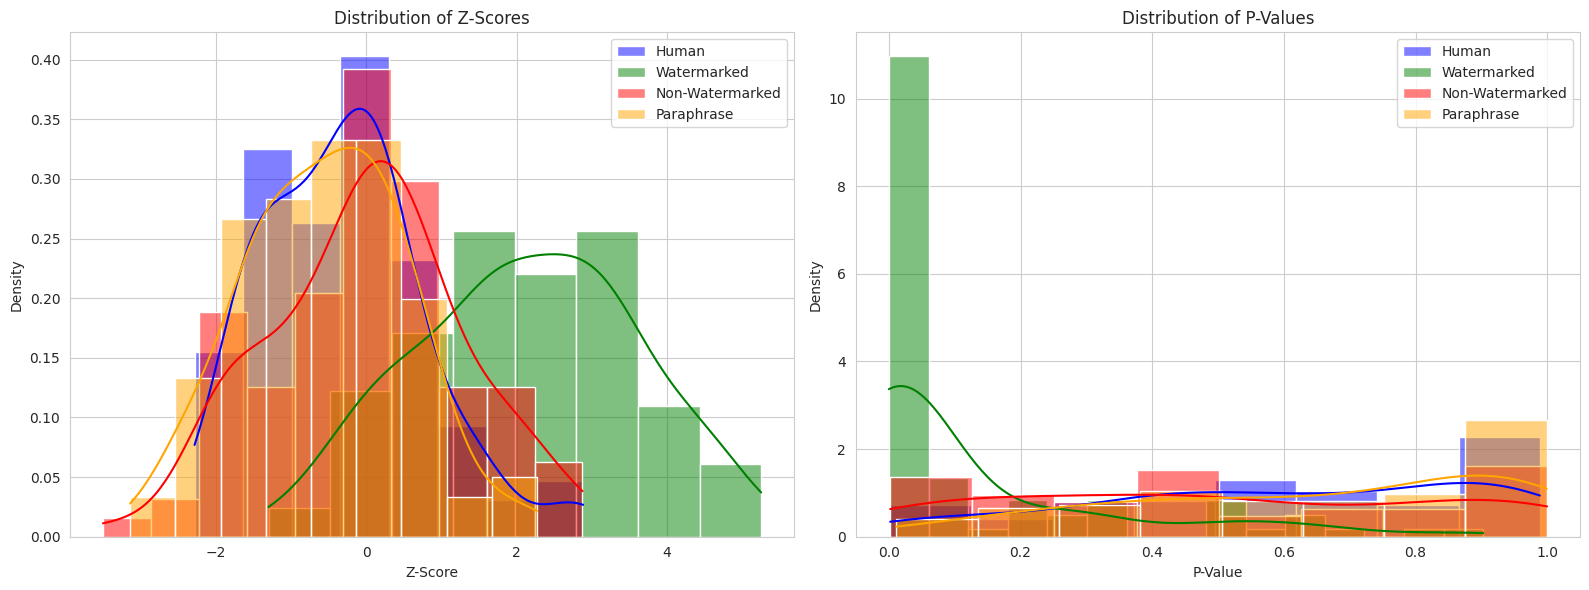

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for the plots
sns.set_style("whitegrid")

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plotting Z-Scores
sns.histplot(evaluation_df['human_z_score'], color='blue', label='Human', kde=True, ax=axes[0], stat='density', alpha=0.5)
sns.histplot(evaluation_df['watermarked_z_score'], color='green', label='Watermarked', kde=True, ax=axes[0], stat='density', alpha=0.5)
sns.histplot(evaluation_df['non_watermarked_z_score'], color='red', label='Non-Watermarked', kde=True, ax=axes[0], stat='density', alpha=0.5)
sns.histplot(evaluation_df['paraphrase_z_score'], color='orange', label='Paraphrase', kde=True, ax=axes[0], stat='density', alpha=0.5)
axes[0].set_title('Distribution of Z-Scores')
axes[0].set_xlabel('Z-Score')
axes[0].set_ylabel('Density')
axes[0].legend()

# Plotting P-Values
sns.histplot(evaluation_df['human_p_value'], color='blue', label='Human', kde=True, ax=axes[1], stat='density', alpha=0.5)
sns.histplot(evaluation_df['watermarked_p_value'], color='green', label='Watermarked', kde=True, ax=axes[1], stat='density', alpha=0.5)
sns.histplot(evaluation_df['non_watermarked_p_value'], color='red', label='Non-Watermarked', kde=True, ax=axes[1], stat='density', alpha=0.5)
sns.histplot(evaluation_df['paraphrase_p_value'], color='orange', label='Paraphrase', kde=True, ax=axes[1], stat='density', alpha=0.5)
axes[1].set_title('Distribution of P-Values')
axes[1].set_xlabel('P-Value')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
evaluation_df.to_csv('evaluation_results.csv', index=False)